# MAGS: Online Hotel-Booking Platform (Polyglot Persistence)

**Module:** BEMM459J, Database Technologies for Business Analytics, University of Exeter Business School
**Type:** Group coursework (4 people). See the README for the full team and an honest breakdown of my contribution.

---

## Business problem
An online travel agency, *MAGS*, needs a back end that can do two different jobs well:

1. **Transactional bookings**: customers, reservations, rooms, invoices and feedback, where correctness and referential integrity matter (you cannot invoice a booking that does not exist).
2. **Fast catalogue search**: a flexible, read-heavy hotel directory (name, star rating, city, country) that changes shape over time and needs to be queried quickly.

A single database is a poor fit for both. This project demonstrates a **polyglot-persistence** design that uses the right store for each job.

## Solution & tech stack
| Layer | Technology | Why |
|---|---|---|
| Transactional core | **SQLite** (relational, 3NF) | ACID guarantees, foreign keys, joins for invoicing/analytics |
| Catalogue / search | **MongoDB** (document store) | schema-flexible, fast reads for a hotel directory |
| Application & analytics | **Python** (`sqlite3`, `pymongo`, `pandas`, `seaborn`) | CRUD layer + descriptive analytics |

## My contribution (Sachin Sharma)
I owned the **relational layer and the analytics**: the 3NF schema design for the six core tables, the Python CRUD helpers over SQLite, the invoice-derivation logic (duration times the summed nightly room price), and the booking/ratings analysis at the end of this notebook. The MongoDB module was built collaboratively. *Published with my teammates' consent.*

## Results at a glance
- A normalised **6-table 3NF schema** (Customer, Booking, Room, Hotel, Invoice, Feedback) with enforced foreign keys.
- A reusable Python **CRUD layer** plus automated **invoice generation** (`Amount = nights × nightly price`).
- A revenue-at-risk analysis over 250 synthetic bookings: which hotels lose the most money to cancellations, and whether guest rating tracks that loss. Every figure is produced by [`analysis.py`](analysis.py); none is typed in by hand.
- A parallel **MongoDB** document collection for the searchable hotel catalogue.

> **Reproducibility note.** This notebook runs top-to-bottom with no manual input. The relational database is rebuilt from [`sql/seed.sql`](sql/seed.sql) (run it once before this notebook, or use the setup cell below). The interactive admin menu now lives in [`app.py`](app.py). The MongoDB section falls back to an in-memory [`mongomock`](https://github.com/mongomock/mongomock) client when no live MongoDB server is present, so the notebook executes cleanly in CI. All data is **synthetic**.


## 1. Setup & database build

We import the analysis stack and (re)build `data/hotel.db` from the seed script so
the notebook is self-contained. `sqlite3` and `pandas` do the heavy lifting.


In [1]:
import os
import sqlite3
import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# Locate the project root (this notebook lives in notebooks/).
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.isdir(os.path.join(PROJECT_ROOT, "sql")):
    PROJECT_ROOT = os.getcwd()  # fallback if run from the repo root

DB_PATH = os.path.join(PROJECT_ROOT, "data", "hotel.db")
SEED_SQL = os.path.join(PROJECT_ROOT, "sql", "seed.sql")
os.makedirs(os.path.dirname(DB_PATH), exist_ok=True)

In [2]:
# Rebuild the database from the seed script so this notebook is reproducible.
# (Equivalent to:  sqlite3 data/hotel.db < sql/seed.sql)
with sqlite3.connect(DB_PATH) as setup_conn, open(SEED_SQL) as fh:
    setup_conn.executescript(fh.read())

conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA foreign_keys = ON;")

# A clean schema means no orphaned foreign keys:
orphans = conn.execute("PRAGMA foreign_key_check;").fetchall()
print("Foreign-key violations:", len(orphans))
print("Tables:", [r[0] for r in conn.execute(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;")])

Foreign-key violations: 0
Tables: ['Booking', 'Customer', 'Feedback', 'Hotel', 'Invoice', 'Room']


## 2. Relational CRUD layer

The helpers below wrap the common create / read / update / delete operations
against SQLite.

**Security note, parameterised queries.** All *values* are passed as `?`
placeholders and bound by the driver, which is the correct defence against SQL
injection. Table/column *names* (which cannot be bind parameters) are restricted
to a fixed allow-list. The original coursework used string concatenation here;
this version has been hardened. The same helpers are packaged in
[`db.py`](db.py) for reuse by the console app.


In [3]:
# Allow-list of valid identifiers: table -> ordered columns.
SCHEMA = {
    "Customer": ["CustomerID", "First_name", "Last_name", "Address",
                 "Postal_code", "Contact_number", "Age"],
    "Booking":  ["BookingID", "Arrival_date", "Checkout_date", "Cancellation",
                 "Duration", "Number_of_guests", "Meal",
                 "CustomerCustomerID", "HotelHotelID"],
    "Hotel":    ["HotelID", "Name", "Contact", "Address",
                 "Postal_code", "Parking_space"],
    "Invoice":  ["InvoiceID", "BookingBookingID", "Amount",
                 "Discount", "Date", "Time"],
    "Room":     ["Room_number", "Room_type", "Price",
                 "HotelHotelID", "BookingBookingID"],
    "Feedback": ["FeedbackID", "BookingBookingID", "Feedback_text",
                 "Rating", "HotelHotelID"],
}

def _check(table, column=None):
    if table not in SCHEMA:
        raise ValueError(f"Unknown table: {table!r}")
    if column is not None and column not in SCHEMA[table]:
        raise ValueError(f"Unknown column {column!r} for {table!r}")

def insert_row(table, values):
    """Insert a full row using a parameterised query (values are bound, not concatenated)."""
    _check(table)
    cols = SCHEMA[table]
    placeholders = ", ".join("?" for _ in cols)
    sql = f"INSERT INTO {table} ({', '.join(cols)}) VALUES ({placeholders})"
    conn.execute(sql, tuple(values))
    conn.commit()

def update_value(table, pk_col, pk_value, set_col, new_value):
    _check(table, pk_col); _check(table, set_col)
    conn.execute(f"UPDATE {table} SET {set_col} = ? WHERE {pk_col} = ?",
                 (new_value, pk_value))
    conn.commit()

def delete_row(table, pk_col, pk_value):
    _check(table, pk_col)
    conn.execute(f"DELETE FROM {table} WHERE {pk_col} = ?", (pk_value,))
    conn.commit()

def get_table(table):
    _check(table)
    return pd.read_sql_query(f"SELECT * FROM {table}", conn)

def get_row(table, pk_col, pk_value):
    _check(table, pk_col)
    return pd.read_sql_query(
        f"SELECT * FROM {table} WHERE {pk_col} = ?", conn, params=(pk_value,))

### CRUD in action

A quick round-trip to show the helpers work: read a table, insert a row, then
delete it again. (The full menu-driven admin tool lives in `app.py` so this
notebook never blocks on `input()`.)


In [4]:
# Read: the Hotel catalogue as stored in the relational core.
get_table("Hotel")

,HotelID,Name,Contact,Address,Postal_code,Parking_space
0,4001,Crowne Plaza London Ealing,02082333200,"Western Avenue, Ealing",W5 1HG,0
1,4002,Dorsett City London,02038051000,9 Aldgate High Street,EC3N 1AH,1
2,4003,The Montana,01803380449,21 Belgrave Rd,Q2 5HU,1
3,4004,Sea Containers London,02037471000,20 Upper Ground,SE1 9PD,0
4,4005,Grand Royale London Hyde Park,02073137900,1-9 Inverness Terrace,W2 3JP,1
5,4006,Park Grand London Hyde Park,02072624521,78-82 Westbourne Terrace,W2 6QA,1
6,4007,The 29 London,02078340205,29-31 St Georges Dr,SW1V 4DG,0
7,4008,Astor Court Hotel,02076364133,20 Hallam St,W1W 6JQ,1
8,4009,New Linden Hotel,02072214321,59 Leinster Square,W2 4PS,1
9,4010,Hampton by Hilton London Waterloo,02074018080,157 Waterloo Rd,SE1 8XA,0


In [5]:
# Create then delete: add a feedback row, confirm the count, remove it.
# One review per booking is now enforced by a UNIQUE constraint, so review a
# booking that has none yet rather than re-reviewing booking 1000001.
free = pd.read_sql_query("""
    SELECT b.BookingID, b.HotelHotelID
      FROM Booking b
     WHERE NOT EXISTS (SELECT 1 FROM Feedback f WHERE f.BookingBookingID = b.BookingID)
     LIMIT 1
""", conn).iloc[0]

before = len(get_table("Feedback"))
insert_row("Feedback", [111, int(free.BookingID), "Great stay, would book again.",
                        5, int(free.HotelHotelID)])
after_insert = len(get_table("Feedback"))
delete_row("Feedback", "FeedbackID", 111)
after_delete = len(get_table("Feedback"))
print(f"Reviewed booking {free.BookingID}")
print(f"Feedback rows -> before: {before}, after insert: {after_insert}, after delete: {after_delete}")

Reviewed booking 1000012
Feedback rows -> before: 152, after insert: 153, after delete: 152


### Why parameterised queries matter

Below, a malicious string is supplied as a *value*. Because it is bound as a
parameter rather than concatenated into the SQL text, it is stored as harmless
literal data. The `Hotel` table is **not** dropped.


In [6]:
malicious = "Smith'); DROP TABLE Hotel;--"
update_value("Customer", "CustomerID", 1001, "Last_name", malicious)
print("Hotel table still present with",
      len(get_table("Hotel")), "rows: injection neutralised.")
# Restore the original value.
update_value("Customer", "CustomerID", 1001, "Last_name", "Bottle")

Hotel table still present with 10 rows: injection neutralised.


### What the schema refuses to store

Three rules are enforced by the database itself rather than by application code,
so they hold no matter which client writes the row:

- a stay must end after it starts (`CHECK (Checkout_date > Arrival_date)`),
- a booking can carry at most one invoice (`UNIQUE`),
- a booking can carry at most one review (`UNIQUE`).

In [7]:
# Each of these used to be accepted silently.
def rejects(label, sql):
    try:
        conn.execute(sql)
    except sqlite3.IntegrityError as exc:
        print(f"rejected   {label}\n           ({exc})")
    else:
        conn.rollback()
        print(f"ACCEPTED   {label}  <- constraint is missing")

rejects("checkout before arrival (used to give a Duration of -9)",
        "INSERT INTO Booking VALUES (1009999,'2022-04-10','2022-04-01',0,NULL,2,0,1001,4001)")
rejects("a second invoice for booking 1000001",
        "INSERT INTO Invoice VALUES (2999,1000001,999,0,'2019-07-19','13:00')")
rejects("a second review for booking 1000001",
        "INSERT INTO Feedback VALUES (199,1000001,'Duplicate review.',5,4001)")

rejected   checkout before arrival (used to give a Duration of -9)
           (CHECK constraint failed: Checkout_date > Arrival_date)
rejected   a second invoice for booking 1000001
           (UNIQUE constraint failed: Invoice.BookingBookingID)
rejected   a second review for booking 1000001
           (UNIQUE constraint failed: Feedback.BookingBookingID)


## 3. Derived business logic: invoice generation

Two values are *derived* rather than entered by hand, mirroring how a real
billing process would work:

- **`Booking.Duration`** = nights between check-out and arrival.
- **`Invoice.Amount`** = `Duration x` the **sum** of the nightly prices of
  **every** room on that booking.

The sum is the part that is easy to get wrong. A booking can hold more than one
room (a family taking two), and it can hold none. A correlated subquery without
an aggregate returns the first matching room only, which silently under-bills
every multi-room booking, and returns `NULL` when there is no room at all.
`SUM` fixes the first case, `COALESCE` the second. `tests/test_hotel_db.py`
holds the regression test.

In [8]:
# Recompute duration and invoice amount in SQL (idempotent).
conn.executescript("""
    UPDATE Booking
       SET Duration = CAST(julianday(Checkout_date) - julianday(Arrival_date) AS INTEGER);

    UPDATE Invoice
       SET Amount = COALESCE((
            SELECT SUM(b.Duration * r.Price)
              FROM Booking b
              JOIN Room    r ON r.BookingBookingID = b.BookingID
             WHERE b.BookingID = Invoice.BookingBookingID
       ), 0);
""")
conn.commit()

# Multi-room bookings are exactly where the aggregate earns its keep.
pd.read_sql_query("""
    SELECT i.InvoiceID, b.BookingID, b.Duration AS nights,
           COUNT(r.Room_number)  AS rooms,
           SUM(r.Price)          AS nightly_total,
           i.Amount,
           b.Duration * MIN(r.Price) AS if_only_one_room_were_billed
      FROM Invoice i
      JOIN Booking b ON b.BookingID = i.BookingBookingID
      JOIN Room    r ON r.BookingBookingID = b.BookingID
     GROUP BY i.InvoiceID, b.BookingID, b.Duration, i.Amount
    HAVING COUNT(r.Room_number) > 1
     ORDER BY i.Amount DESC
     LIMIT 5
""", conn)

,InvoiceID,BookingID,nights,rooms,nightly_total,Amount,if_only_one_room_were_billed
0,3157,1000167,14,2,504,7056,3444
1,3129,1000139,13,2,513,6669,3263
2,3158,1000168,13,2,512,6656,3250
3,3059,1000069,12,2,519,6228,3084
4,3106,1000116,14,2,439,6146,3010


## 4. Analytics: which hotels lose the most revenue to cancellations?

The transactional core now carries 250 bookings across 10 hotels, which is
enough to ask a question with a decision attached to it:

> **Cancellations erode booked revenue. Which properties are costing us the
> most, and does weak guest satisfaction travel with the loss?**

Ranking hotels by cancellation *rate* is the obvious move and it is the wrong
one: a small, cheap hotel can cancel a third of its bookings and still cost less
than a large, expensive one cancelling a quarter. The ranking below is by money.

> **The data is synthetic and the structure is deliberate.** `sql/seed.sql`
> generates lower-rated hotels with higher cancellation rates on purpose, so the
> relationship found here was put there by construction. What is being shown is
> the method, not a fact about real hotels.

In [9]:
# The same aggregation the README quotes, imported rather than re-typed
# so the notebook and `python analysis.py` cannot drift apart.
import sys
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
import analysis

at_risk = analysis.hotel_revenue_at_risk(conn)
at_risk[["hotel", "bookings", "cancel_rate_pct", "booked_revenue",
         "lost_revenue", "lost_share_pct", "avg_rating", "reviews"]]

,hotel,bookings,cancel_rate_pct,booked_revenue,lost_revenue,lost_share_pct,avg_rating,reviews
0,Hampton by Hilton London Waterloo,29,27.6,75252,22563,30.0,1.31,13
1,Grand Royale London Hyde Park,29,20.7,52266,14857,28.4,2.15,20
2,Astor Court Hotel,29,20.7,38026,7891,20.8,3.00,19
3,The Montana,20,30.0,21435,3125,14.6,1.30,10
4,New Linden Hotel,18,11.1,31964,2660,8.3,4.00,10
5,Crowne Plaza London Ealing,20,10.0,17569,2115,12.0,1.75,8
6,The 29 London,28,3.6,25066,1240,4.9,3.67,18
7,Sea Containers London,18,5.6,42791,1040,2.4,4.00,12
8,Park Grand London Hyde Park,28,3.6,71999,956,1.3,4.84,19
9,Dorsett City London,31,3.2,26216,111,0.4,4.78,23


### 4.1 How much is at stake, and how concentrated is it?

In [10]:
booked = int(at_risk["booked_revenue"].sum())
lost   = int(at_risk["lost_revenue"].sum())
worst3 = at_risk.head(3)

print(f"Booked revenue           GBP {booked:,}")
print(f"Lost to cancellations    GBP {lost:,}  ({100 * lost / booked:.1f}% of booked)")
print(f"Concentrated in 3 hotels GBP {int(worst3['lost_revenue'].sum()):,} "
      f"({100 * worst3['lost_revenue'].sum() / lost:.1f}% of the loss from "
      f"{100 * worst3['bookings'].sum() / at_risk['bookings'].sum():.1f}% of bookings)")

Booked revenue           GBP 402,584
Lost to cancellations    GBP 56,558  (14.0% of booked)
Concentrated in 3 hotels GBP 45,311 (80.1% of the loss from 34.8% of bookings)


### 4.2 Does guest rating move with the cancellation rate?

Pearson r (avg rating vs cancellation rate) = -0.841 over 10 hotels


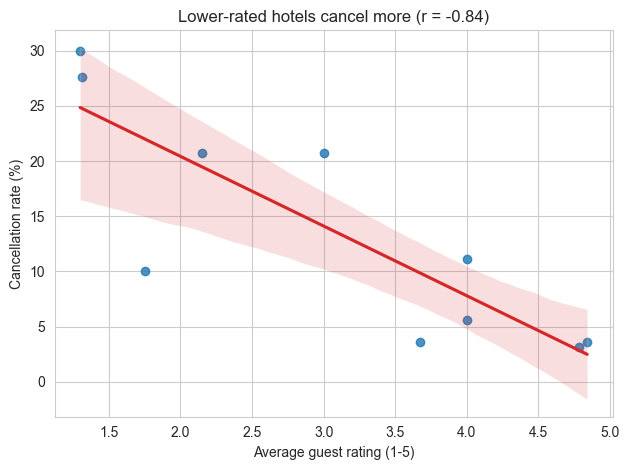

In [11]:
corr = at_risk["avg_rating"].corr(at_risk["cancel_rate_pct"])
print(f"Pearson r (avg rating vs cancellation rate) = {corr:.3f} over {len(at_risk)} hotels")

sns.set_style("whitegrid")
ax = sns.regplot(x="avg_rating", y="cancel_rate_pct", data=at_risk,
                 color="tab:blue", line_kws={"color": "tab:red"})
ax.set_title(f"Lower-rated hotels cancel more (r = {corr:.2f})")
ax.set_xlabel("Average guest rating (1-5)")
ax.set_ylabel("Cancellation rate (%)")
plt.tight_layout()
plt.show()

### 4.3 Rate or money: do the two rankings agree?

This is the point of the analysis. If both rankings named the same hotel there
would be no reason to compute revenue at all.

In [12]:
by_money = at_risk.iloc[0]
by_rate  = at_risk.sort_values("cancel_rate_pct", ascending=False).iloc[0]

print(f"Worst by cancellation rate : {by_rate['hotel']:<34} "
      f"{by_rate['cancel_rate_pct']:>5}%   GBP {int(by_rate['lost_revenue']):>7,} lost")
print(f"Worst by revenue lost      : {by_money['hotel']:<34} "
      f"{by_money['cancel_rate_pct']:>5}%   GBP {int(by_money['lost_revenue']):>7,} lost")
print()
print("Same hotel?" , by_money["hotel"] == by_rate["hotel"])

Worst by cancellation rate : The Montana                         30.0%   GBP   3,125 lost
Worst by revenue lost      : Hampton by Hilton London Waterloo   27.6%   GBP  22,563 lost

Same hotel? False


### 4.4 Revenue lost, by hotel

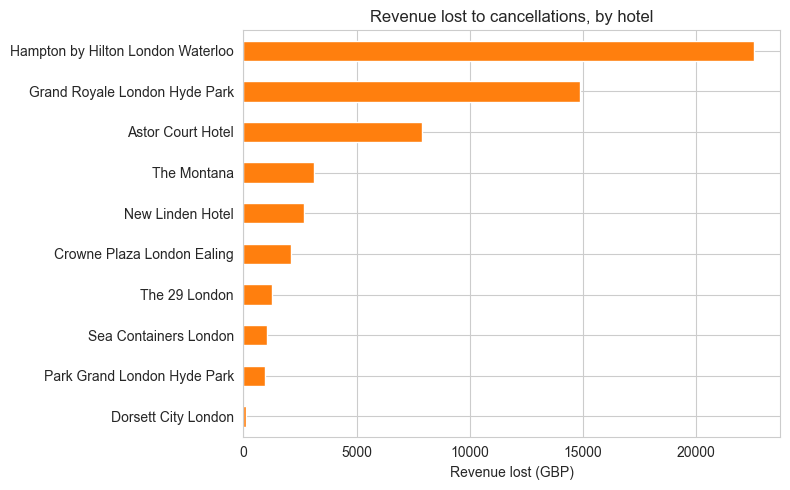

In [13]:
ax = at_risk.sort_values("lost_revenue").plot.barh(
    x="hotel", y="lost_revenue", color="tab:orange", legend=False, figsize=(8, 5))
ax.set_title("Revenue lost to cancellations, by hotel")
ax.set_xlabel("Revenue lost (GBP)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. NoSQL layer: MongoDB hotel catalogue

The searchable hotel directory is modelled as MongoDB documents. A document
store suits this read-heavy, schema-flexible catalogue, whereas the
transactional core above stays relational.

**Running without a database daemon.** The cell below tries to reach a local
MongoDB server; if none is running it transparently falls back to an in-memory
[`mongomock`](https://github.com/mongomock/mongomock) client, so the notebook
runs end-to-end in CI. In the original coursework this section used live
`pymongo` plus `ipywidgets` text boxes for data entry; the data-entry widgets
have been replaced with plain dictionary inserts so the notebook is
non-interactive.


In [14]:
# Connect to MongoDB if available; otherwise use an in-memory mongomock client.
USING_MONGOMOCK = False
try:
    import pymongo
    client = pymongo.MongoClient("mongodb://localhost:27017/",
                                 serverSelectionTimeoutMS=800)
    client.server_info()  # forces a connection attempt
    print("Connected to a live MongoDB server.")
except Exception:
    import mongomock
    client = mongomock.MongoClient()
    USING_MONGOMOCK = True
    print("No live MongoDB found - using an in-memory mongomock client.")

hotel_db = client["hotel_db"]
hotel_records = hotel_db["hotel_records"]
hotel_records.delete_many({})  # start clean

No live MongoDB found - using an in-memory mongomock client.


DeleteResult({'connectionId': 0, 'n': 0, 'ok': 1.0, 'err': None}, acknowledged=True)

In [15]:
def save_hotel(record):
    """Insert one hotel document into the catalogue."""
    result = hotel_records.insert_one(record)
    return result.inserted_id is not None

# Seed the catalogue (replaces the interactive widget form).
catalogue = [
    {"ID": "4002", "NAME": "Dorsett City London",
     "STAR": "4", "CITY": "London", "COUNTRY": "UK"},
    {"ID": "4005", "NAME": "Grand Royale London Hyde Park",
     "STAR": "4", "CITY": "London", "COUNTRY": "UK"},
    {"ID": "4010", "NAME": "Hampton by Hilton London Waterloo",
     "STAR": "3", "CITY": "London", "COUNTRY": "UK"},
]
for hotel in catalogue:
    save_hotel(hotel)

print("Documents in catalogue:", hotel_records.count_documents({}))

Documents in catalogue: 3


In [16]:
# Read back the catalogue as a DataFrame (a typical search/read operation).
results = hotel_records.find()
pd.DataFrame(results, columns=["ID", "NAME", "STAR", "CITY", "COUNTRY"])

,ID,NAME,STAR,CITY,COUNTRY
0,4002,Dorsett City London,4,London,UK
1,4005,Grand Royale London Hyde Park,4,London,UK
2,4010,Hampton by Hilton London Waterloo,3,London,UK


In [17]:
# Delete: documents can be removed by any field (here, by ID).
def delete_hotel(hotel_id):
    result = hotel_records.delete_one({"ID": hotel_id})
    return result.deleted_count

print("Deleted:", delete_hotel("4010"), "document(s)")
print("Remaining:", hotel_records.count_documents({}))

Deleted: 1 document(s)
Remaining: 2


## 6. Summary & limitations

**What this notebook demonstrated**
- A normalised 6-table 3NF relational schema with enforced foreign keys.
- A parameterised Python CRUD layer over SQLite, with an allow-list for identifiers.
- Constraints the database enforces itself: a stay must end after it starts, and a
  booking carries at most one invoice and at most one review.
- Derived invoicing: `Amount = nights x SUM(nightly price of every room on the booking)`.
- A revenue-at-risk analysis that ranks hotels by money lost to cancellations
  rather than by cancellation rate, and tests whether rating moves with it.
- A parallel MongoDB document catalogue for searchable hotel data.

**Limitations & next steps** (see the README for the full list)
- **Synthetic data** only. The generator deliberately correlates low ratings with
  high cancellation rates, so the relationship in section 4 is recovered structure,
  not evidence about real hotels.
- **Single-node** SQLite/MongoDB, with no replication, sharding or concurrency tuning.
- **No authentication or access control.** This is a coursework data layer, not a
  production service.
- `Invoice.Discount` is stored but never applied to `Amount`. That was true of the
  original coursework and has been left alone rather than guessed at.
- Next: an API layer over the CRUD helpers, and an end-to-end sync between the
  relational core and the search catalogue.

In [18]:
conn.close()
print("Done.")

Done.
